In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [14]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_layers, number_of_classes):
        self.input_size = input_size
        self.hidden_layers = hidden_layers
        self.num_of_classes = number_of_classes
        self.dimensions = [input_size] + list(hidden_layers) + [number_of_classes]
        self.parameters = self._initialize_parameters()
        
    def _initialize_parameters(self):
        np.random.seed(1)
        parameters = {}
        for i in range(1, len(self.dimensions)):
            parameters[f'W{i}'] = np.random.randn(self.dimensions[i], self.dimensions[i-1]) * 0.01
            parameters[f'b{i}'] = np.zeros((self.dimensions[i], 1))
        return parameters
    
    def _forward_propagation(self, X):
        activations = {'A0': X}
        depth = len(self.parameters) // 2
        for i in range(1, depth + 1):
            Z = self.parameters[f'W{i}'] @ activations[f'A{i-1}'] + self.parameters[f'b{i}']
            activations[f'A{i}'] = np.maximum(0, Z)
        return activations
    
    def _backward_propagation(self, y, activations):
        m = y.shape[1]
        depth = len(self.parameters) // 2
        gradients = {}
        dA = activations[f'A{depth}'] - y
        dZ = dA * (activations[f'A{depth}'] > 0)
        for i in range(depth, 0, -1):
            gradients[f'dW{i}'] = (1 / m) * (dZ @ activations[f'A{i-1}'].T)
            gradients[f'db{i}'] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
            if i > 1:
                dA_prev = self.parameters[f'W{i}'].T @ dZ
                dZ = dA_prev * (activations[f'A{i-1}'] > 0)
        return gradients
    
    def _update(self, gradients, learning_rate):
        depth = len(self.parameters) // 2
        for i in range(1, depth + 1):
            self.parameters[f'W{i}'] -= learning_rate * gradients[f'dW{i}']
            self.parameters[f'b{i}'] -= learning_rate * gradients[f'db{i}']
    
    def predict(self, X):
        activations = self._forward_propagation(X)
        depth = len(self.parameters) // 2
        return np.argmax(activations[f'A{depth}'], axis=0)
    
    def fit(self, X, y_onehot, y_labels, learning_rate=0.01, n_iters=1000):
        training_history = np.zeros((n_iters, 2))
        depth = len(self.parameters) // 2
        for i in range(n_iters):
            activations = self._forward_propagation(X)
            gradients = self._backward_propagation(y_onehot, activations)
            self._update(gradients, learning_rate)
            Af = activations[f'A{depth}']
            loss = -np.mean(np.sum(y_onehot * np.log(Af + 1e-15), axis=0))
            training_history[i, 0] = loss
            y_pred = np.argmax(Af, axis=0)
            training_history[i, 1] = accuracy_score(y_labels, y_pred)
        return training_history

In [29]:
X_data = np.array([[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0],
                  [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0],
                  [0.5, 0.3, 0.8, 0.2, 0.9, 0.4, 0.6],
                  [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5],
                  [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7],
                  [9.0, 8.0, 7.0, 6.0, 5.0, 4.0, 3.0],
                  [2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4],
                  [5.0, 4.0, 3.0, 2.0, 1.0, 0.0, 8.0],
                  [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
                  [7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 1.0]])

y = np.array([0, 1, 2, 0, 1, 2, 0])
X_train = X_data[:, :5]
y_train = y[:5]
X_test = X_data[:, 5:]
y_test = y[5:]
y_onehot = np.zeros((3, len(y_train)))
y_onehot[y_train, np.arange(len(y_train))] = 1
nn = NeuralNetwork(input_size=10, hidden_layers=(20,), number_of_classes=3)
history = nn.fit(X_train, y_onehot, y_train, learning_rate=0.1, n_iters=1000)

predictions = nn.predict(X_test)
print(f"Train labels: {y_train}")
print(f"Test labels:  {y_test}")
print(f"Predictions:  {predictions}")
print(f"Test Accuracy: {accuracy_score(y_test, predictions):.2f}")

Train labels: [0 1 2 0 1]
Test labels:  [2 0]
Predictions:  [1 1]
Test Accuracy: 0.00


In [30]:
def generate_dataset(image_size, samples_per_class, noise_white=0.05, noise_black=0.05):
    np.random.seed(42)
    
    def add_noise(image):
        noisy = image.copy().astype(float)
        noisy[image == 1] += np.random.uniform(-noise_white, noise_white, np.sum(image == 1))
        noisy[image == 0] += np.random.uniform(-noise_black, noise_black, np.sum(image == 0))
        return np.clip(noisy, 0, 1)
    
    def create_square():
        img = np.zeros((image_size, image_size))
        half = np.random.randint(6, 13)
        center = image_size // 2
        img[center-half:center+half, center-half:center+half] = 1
        return img
    
    def create_lines():
        img = np.zeros((image_size, image_size))
        center = image_size // 2
        for y_center in [center-5, center, center+5]:
            y_start = max(0, y_center - 1)
            y_end = min(image_size, y_center + 2)
            img[y_start:y_end, :] = 1
        return img
    
    def create_triangle():
        img = np.zeros((image_size, image_size))
        h = np.random.randint(8, 17)
        cx = image_size // 2
        top = cx - h // 2
        for row in range(h):
            width = int((row / h) * h)
            img[top + row, cx-width:cx+width+1] = 1
        return img
    
    generators = [create_square, create_lines, create_triangle]
    images, labels = [], []
    for label, gen in enumerate(generators):
        for _ in range(samples_per_class):
            img = gen()
            noisy = add_noise(img)
            images.append(noisy.flatten())
            labels.append(label)
    images = np.array(images)
    labels = np.array(labels)
    shuffle_idx = np.random.permutation(len(labels))
    return images[shuffle_idx], labels[shuffle_idx]

Test Accuracy: 0.9333

predictions and original labels:
test image 0: Predicted = 2, Actual = 2
test image 1: Predicted = 1, Actual = 1
test image 2: Predicted = 0, Actual = 0
test image 3: Predicted = 1, Actual = 1
test image 4: Predicted = 2, Actual = 2


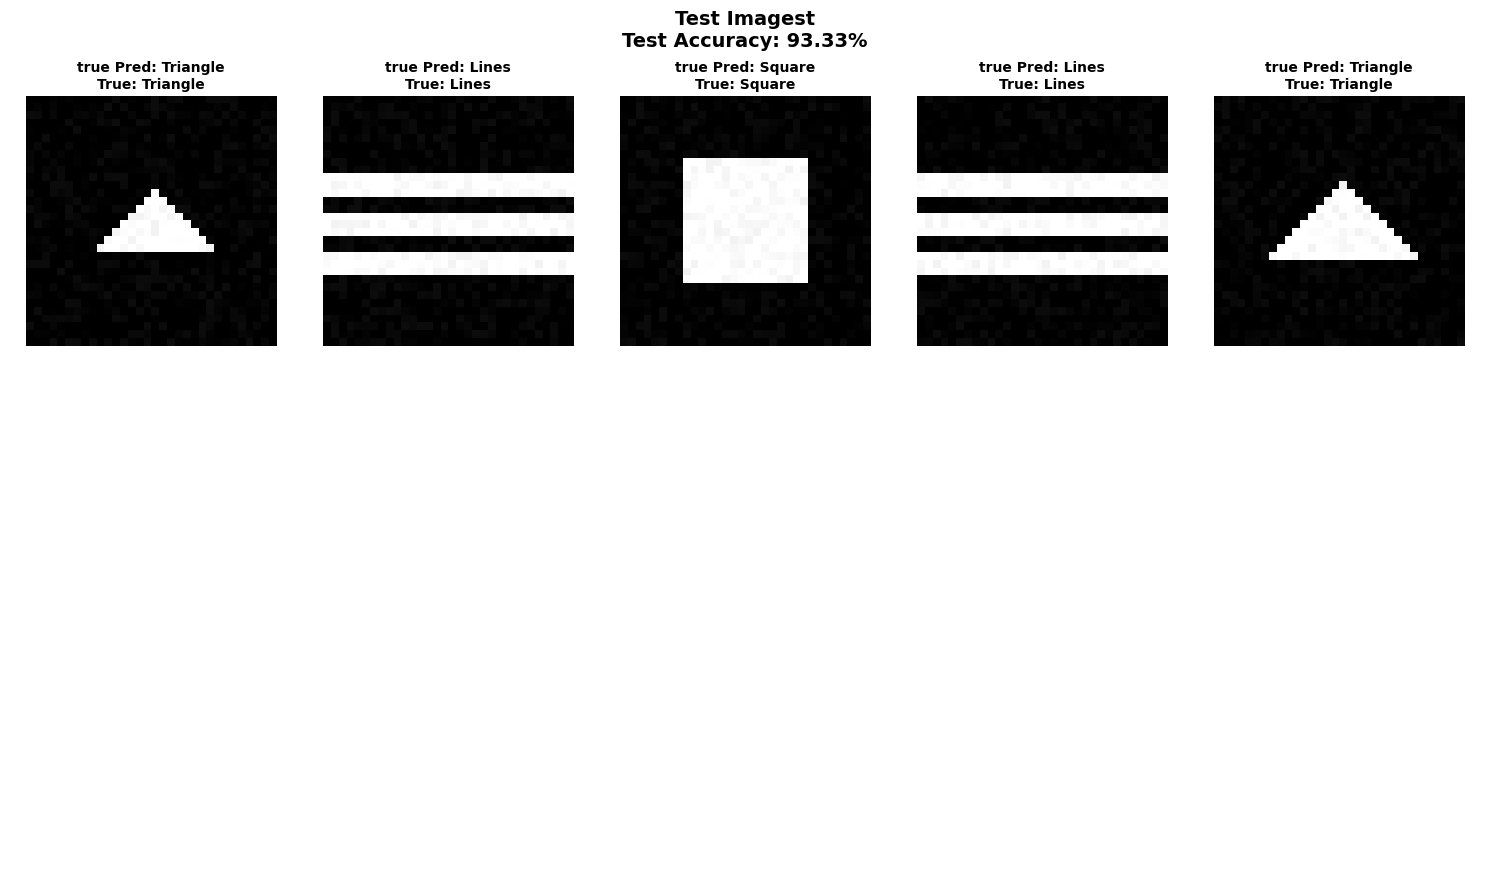

In [ ]:
image_size = 32
samples_per_class = 50
num_classes = 3

images, labels = generate_dataset(image_size, samples_per_class)

split_idx = int(0.9 * len(images))
X_train = images[:split_idx].T
y_train = labels[:split_idx]
X_test = images[split_idx:].T
y_test = labels[split_idx:]

y_onehot = np.zeros((num_classes, len(y_train)))
y_onehot[y_train, np.arange(len(y_train))] = 1

neural_net = NeuralNetwork(input_size=image_size * image_size, hidden_layers=(128, 64), number_of_classes=num_classes)
history = neural_net.fit(X_train, y_onehot, y_train, learning_rate=0.01, n_iters=1500)

predictions = neural_net.predict(X_test)
test_accuracy = accuracy_score(y_test, predictions)
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\npredictions and original labels:")
for i in range(min(5, len(y_test))):
    print(f"test image {i}: Predicted = {predictions[i]}, Actual = {y_test[i]}")

class_names = ['Square', 'Lines', 'Triangle']
num_display = min(5, len(y_test))
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.ravel()

for i in range(num_display):
    img = X_test[:, i].reshape(image_size, image_size)
    pred_class = class_names[predictions[i]]
    true_class = class_names[y_test[i]]
    
    if predictions[i] == y_test[i]:
        color = 'black'
        result = 'true'
    else:
        color = 'black'
        result = 'false'
    
    axes[i].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f'{result} Pred: {pred_class}\nTrue: {true_class}',  color=color, fontsize=10, fontweight='bold')
    axes[i].axis('off')

for i in range(num_display, 15):
    axes[i].axis('off')

plt.suptitle(f'Test Imagest\nTest Accuracy: {test_accuracy:.2%}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()